In [1]:
import os
import numpy as np
import pandas as pd
from sub_tsmd import generate, plot_motif_sets, plot_motif_sets_marking

In [2]:
MAX_DIMENSION = 12
MOTIFS = [
    lambda x: np.sin(np.linspace(0, 2 * np.pi, x)),  # Sinusoidal 
    lambda x: np.concatenate([np.ones(int(np.ceil(x/2))), -1 * np.ones(int(np.floor(x/2)))]),  # Square wave
    lambda x: np.exp(-np.linspace(0, 2, x)) * np.sin(2 * np.pi * np.linspace(0, 1, x)),  # Damped sine
    lambda x: np.cos(np.linspace(0, 2 * np.pi, x)),  # Cosine wave
    lambda x: np.linspace(-1, 1, x),  # Linear increasings
    lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
    lambda x: np.sign(np.sin(np.linspace(0, 4 * np.pi, x))),  # Square wave-like signal
    lambda x: np.sin(4 * np.pi * np.linspace(0, 1, x)),  # Higher frequency sine
    lambda x: np.linspace(1, -1, x)  # Linear decreasing
]
NB_REPS_PER_MOTIF = 5

print('Dimension:', MAX_DIMENSION)
print('Number of distinct motifs:', len(MOTIFS))
print('Number time series per motif:', NB_REPS_PER_MOTIF)
print('Total:', MAX_DIMENSION*len(MOTIFS)*NB_REPS_PER_MOTIF, f"(={MAX_DIMENSION}*{len(MOTIFS)}*{NB_REPS_PER_MOTIF})")

Dimension: 12
Number of distinct motifs: 9
Number time series per motif: 5
Total: 540 (=12*9*5)


## Example

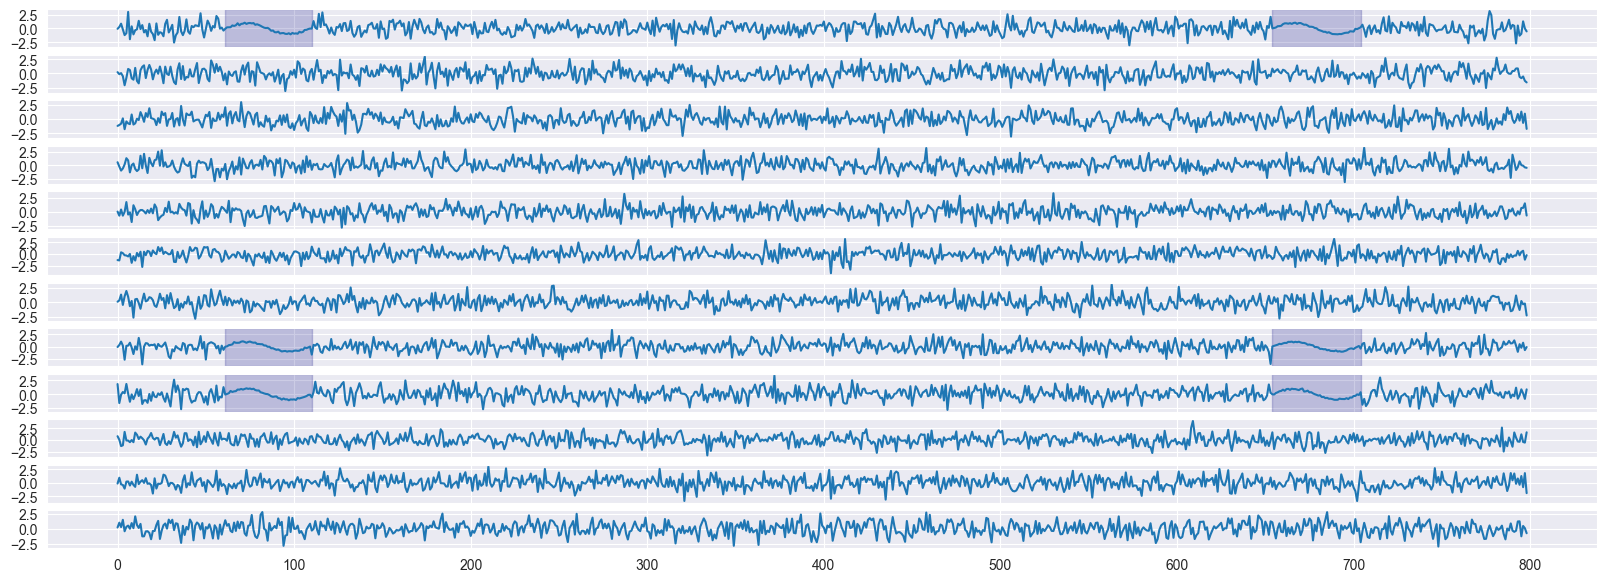

In [3]:
X, y = generate(
    dimension=MAX_DIMENSION,
    nb_motif_sets=1,
    min_motif_set_size=2,
    max_motif_set_size=2,
    min_motif_dimension=3,
    max_motif_dimension=3,
    univariate_motifs=[MOTIFS[0]], 
    min_motif_length=50,
    max_motif_length=50,
    white_space=700, 
    nb_motif_repositions=0,
    noise_general=0.1,
    noise_non_motif=1,
    seed=42
)
plot_motif_sets(X, y);

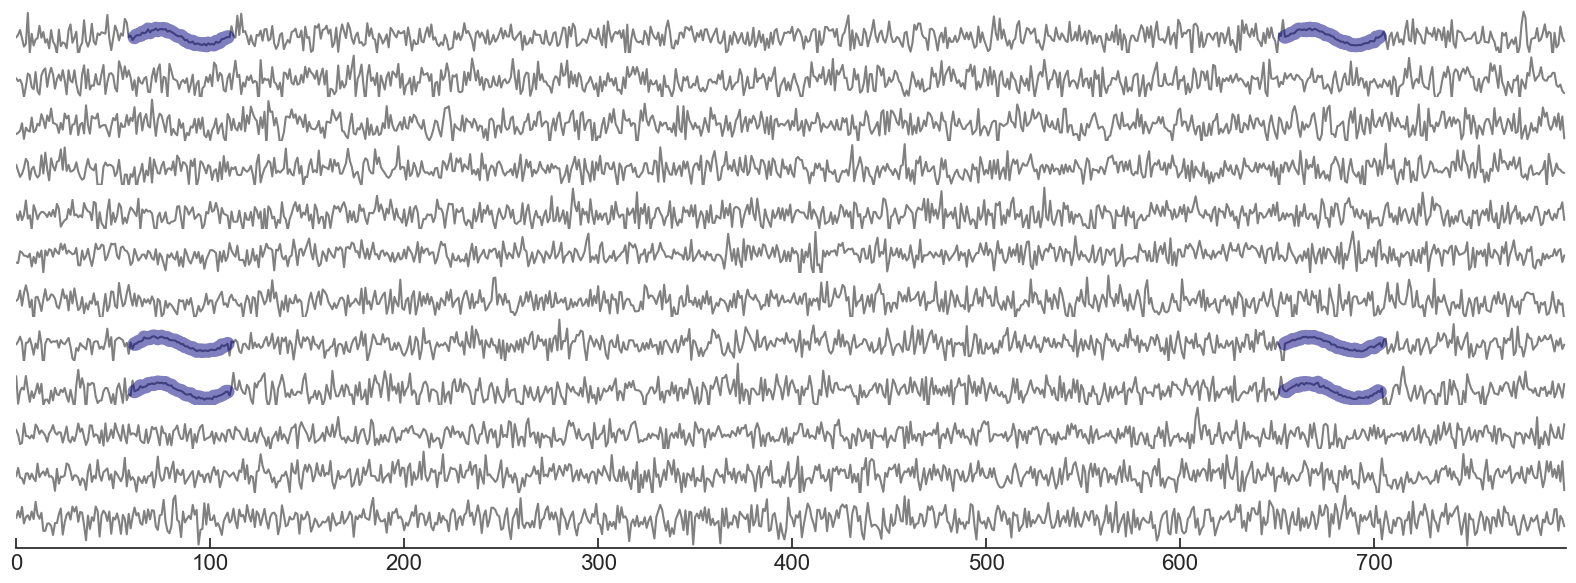

In [8]:
def format_figure(f, x_shape, labels = None, fontsize=16, tick_length=7, hspace=-0.2, labelpad=20):
    for i, ax in enumerate(f.axes):
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_xlim([0, x_shape[0]])
        ax.grid(False)
        
        if labels is not None:
            ax.set_ylabel(f'{labels[i]}', labelpad=labelpad, fontsize=fontsize)
            ax.yaxis.label.set(rotation='horizontal', ha='right', va='top')
            
        if i != x_shape[1] - 1:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', direction='out', length=0) # Hide the ticks for all but last axis
        else:
            ax.spines['bottom'].set_visible(True)
            ax.tick_params(axis='x', direction='in', length=tick_length, which='major', labelsize=fontsize) # Hide the ticks for all but last axis
    
    f.subplots_adjust(hspace=hspace)
    return f

import seaborn as sns
sns.set_theme(style="ticks")
fig = plot_motif_sets_marking(X, y)
format_figure(fig, X.shape)
fig.savefig("fig-example-motif-pair.png", bbox_inches='tight')

## Benchmark set

In [5]:
import scipy

def get_r(X, y, l_min, l_max):
    
    r_max = -1
    length = int(np.round((l_min + l_max) / 2))
    
    for ts, gt in zip(X, y):
        
        for (mask, motif_set) in gt:
            
            instances = np.empty(shape=(motif_set.shape[0], mask.sum(), length))
            for i, motif in enumerate(motif_set):
                c = -1
                for d in range(ts.shape[1]):
                    if not mask[d]:
                        continue
                    c += 1
                    instances[i, c, :] = scipy.signal.resample(ts[motif[0, c]:motif[1, c], d], length)      

            # Compute the distance matrix
            N, D, T = instances.shape
            distance_matrix = scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(instances.reshape(N, D*T), metric='euclidean'))
            
            # Find the R for this class, and update r_max
            r = np.min(np.max(distance_matrix, axis=0))
            if r > r_max:
                r_max = r
    
    return r_max

In [6]:
columns = {'ds_name': str, 'l_min': int, 'l_max': int, 'D': int, 'k_max' : int, 'r': float, 'n_avg_train': int, 'n_avg_test': int, 'n_avg': int}
metadata = pd.DataFrame(columns, index=[])
    
MIN_MOTIF_LENGTH = 50
MAX_MOTIF_LENGTH = MIN_MOTIF_LENGTH
    
for subspace_d in range(1, MAX_DIMENSION+1):
    
    for motif_id, motif in enumerate(MOTIFS):
        name = f"subspace={subspace_d}-motif={motif_id}"
        print(name)
        
        ts, gt = [], []
        start_seed = subspace_d * 10000 + motif_id * 100
        for i in range(NB_REPS_PER_MOTIF):
            X, y = generate(
                dimension=MAX_DIMENSION,
                min_motif_dimension=subspace_d,
                max_motif_dimension=subspace_d,
                univariate_motifs=[motif], 
                # Ensure a single motif pair
                nb_motif_sets=1,
                min_motif_set_size=2,
                max_motif_set_size=2,
                # Fix the following configurations
                min_motif_length=MIN_MOTIF_LENGTH,
                max_motif_length=MAX_MOTIF_LENGTH,
                white_space=700, 
                nb_motif_repositions=0,
                noise_general=0.1,
                noise_non_motif=1,
                # Reproducibility
                seed=start_seed + i
            )
            ts.append(X)
            gt.append(y)
            
        if not os.path.exists(name.lower()):
            os.mkdir(name.lower())       
            
        pd.DataFrame(data={'ts': ts, 'gt': gt}).to_pickle(f'{name.lower()}/test.pkl')
        metadata.loc[len(metadata)] = {
            'ds_name': name.lower(), 
            'D': MAX_DIMENSION, 
            'l_min': MIN_MOTIF_LENGTH, 
            'l_max': MAX_MOTIF_LENGTH, 
            'k_max': 2, 
            'N_max': 1,
            'r': get_r(ts, gt, MIN_MOTIF_LENGTH, MAX_MOTIF_LENGTH),
            'n_avg_test': np.mean([i.shape[0] for i in ts]), 
            'n_avg': np.mean([i.shape[0] for i in ts])
        }
        
metadata

subspace=1-motif=0
subspace=1-motif=1
subspace=1-motif=2
subspace=1-motif=3
subspace=1-motif=4
subspace=1-motif=5
subspace=1-motif=6
subspace=1-motif=7
subspace=1-motif=8
subspace=2-motif=0
subspace=2-motif=1
subspace=2-motif=2
subspace=2-motif=3
subspace=2-motif=4
subspace=2-motif=5
subspace=2-motif=6
subspace=2-motif=7
subspace=2-motif=8
subspace=3-motif=0
subspace=3-motif=1
subspace=3-motif=2
subspace=3-motif=3
subspace=3-motif=4
subspace=3-motif=5
subspace=3-motif=6
subspace=3-motif=7
subspace=3-motif=8
subspace=4-motif=0
subspace=4-motif=1
subspace=4-motif=2
subspace=4-motif=3
subspace=4-motif=4
subspace=4-motif=5
subspace=4-motif=6
subspace=4-motif=7
subspace=4-motif=8
subspace=5-motif=0
subspace=5-motif=1
subspace=5-motif=2
subspace=5-motif=3
subspace=5-motif=4
subspace=5-motif=5
subspace=5-motif=6
subspace=5-motif=7
subspace=5-motif=8
subspace=6-motif=0
subspace=6-motif=1
subspace=6-motif=2
subspace=6-motif=3
subspace=6-motif=4
subspace=6-motif=5
subspace=6-motif=6
subspace=6-m

,ds_name,l_min,l_max,D,k_max,r,n_avg_train,n_avg_test,n_avg
0,subspace=1-motif=0,50,50,12,2,1.149541,NaN,799.0,799.0
1,subspace=1-motif=1,50,50,12,2,1.515382,NaN,799.4,799.4
2,subspace=1-motif=2,50,50,12,2,1.130537,NaN,798.8,798.8
3,subspace=1-motif=3,50,50,12,2,1.146314,NaN,799.0,799.0
4,subspace=1-motif=4,50,50,12,2,1.204275,NaN,799.6,799.6
...,...,...,...,...,...,...,...,...,...
103,subspace=12-motif=4,50,50,12,2,3.719853,NaN,798.2,798.2
104,subspace=12-motif=5,50,50,12,2,3.547529,NaN,799.4,799.4
105,subspace=12-motif=6,50,50,12,2,3.586406,NaN,798.8,798.8
106,subspace=12-motif=7,50,50,12,2,3.496560,NaN,799.2,799.2


In [7]:
metadata = metadata.set_index('ds_name')
metadata.to_csv('metadata.csv')